# SQL Summative Lab

## Part 1: Guided SQL Series

**Business Understanding:** Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

**Data Understanding:** The database contains 8 tables: customers, orders, orderdetails, payments, products, productlines, employees, and offices - connected through foreign key relationships as shown in the ERD.

## Step 1: Connect to Data

In [1]:
# Import necessary libraries using standard aliases
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Establish connection to the database
conn = sqlite3.connect('data.sqlite')

# Verify connection by listing all available tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print('Connected successfully!')
print('Available tables:', tables['name'].tolist())

Connected successfully!
Available tables: ['orderdetails', 'payments', 'offices', 'customers', 'orders', 'productlines', 'products', 'employees']


## Step 2: Limited Edition California Product

Return California customers with a credit limit over 25,000 for targeted promotional marketing.

In [2]:
query_2 = """
SELECT customerName,
       contactFirstName,
       contactLastName,
       phone,
       city,
       state,
       creditLimit
FROM customers
WHERE state = 'CA'
  AND creditLimit > 25000
ORDER BY creditLimit DESC;
"""

california_high_credit = pd.read_sql(query_2, conn)
print(f'California customers with credit limit > $25,000: {len(california_high_credit)}')
california_high_credit

California customers with credit limit > $25,000: 11


,customerName,contactFirstName,contactLastName,phone,city,state,creditLimit
0,Toys4GrownUps.com,Julie,Young,6265557265,Pasadena,CA,90700.00
1,Technics Stores Inc.,Juri,Hashimoto,6505556809,Burlingame,CA,84600.00
2,The Sharp Gifts Warehouse,Sue,Frick,4085553659,San Jose,CA,77600.00
3,Mini Wheels Co.,Julie,Murphy,6505555787,San Francisco,CA,64600.00
4,Signal Collectibles Ltd.,Sue,Taylor,4155554312,Brisbane,CA,60300.00
5,"Men 'R' US Retailers, Ltd.",Brian,Chandler,2155554369,Los Angeles,CA,57700.00
6,West Coast Collectables Co.,Steve,Thompson,3105553722,Burbank,CA,55400.00
7,Mini Gifts Distributors Ltd.,Susan,Nelson,4155551450,San Rafael,CA,210500.00
8,Boards & Toys Co.,Mary,Young,3105552373,Glendale,CA,11000.00
9,Collectable Mini Designs Co.,Valarie,Thompson,7605558146,San Diego,CA,105000.00


## Step 3: International Collectable Campaign

Return non-US customers whose name contains 'Collect' for the international marketing campaign.

In [3]:
query_3 = """
SELECT customerName,
       contactFirstName,
       contactLastName,
       phone,
       city,
       country
FROM customers
WHERE country != 'USA'
  AND customerName LIKE '%Collect%'
ORDER BY country;
"""

international_collect = pd.read_sql(query_3, conn)
print(f'International Collect customers found: {len(international_collect)}')
international_collect

International Collect customers found: 15


,customerName,contactFirstName,contactLastName,phone,city,country
0,"Australian Collectors, Co.",Peter,Ferguson,03 9520 4555,Melbourne,Australia
1,"Australian Collectables, Ltd",Sean,Clenahan,61-9-3844-6555,Glen Waverly,Australia
2,Salzburg Collectables,Georg,Pipps,6562-9555,Salzburg,Austria
3,"Royal Canadian Collectables, Ltd.",Elizabeth,Lincoln,(604) 555-4555,Tsawassen,Canada
4,Heintze Collectables,Palle,Ibsen,86 21 3555,Århus,Denmark
5,Reims Collectables,Paul,Henriot,26.47.1555,Reims,France
6,Stuttgart Collectable Exchange,Rita,Müller,0711-555361,Stuttgart,Germany
7,"Bavarian Collectables Imports, Co.",Michael,Donnermeyer,+49 89 61 08 9555,Munich,Germany
8,"King Kong Collectables, Co.",Mike,Gao,+852 2251 1555,Central Hong Kong,Hong Kong
9,"Clover Collections, Co.",Dean,Cassidy,+353 1862 1555,Dublin,Ireland


### Reflection - Step 3

The WHERE clause in the query above uses **two conditions** joined by the `AND` operator, meaning both must be true for a row to be returned:

1. `country != 'USA'` - This filters out any customer based in the United States. The `!=` operator means "not equal to", so only international customers pass through this filter.

2. `customerName LIKE '%Collect%'` - The `LIKE` operator performs a **pattern match** on the customer name. The `%` symbols are wildcards, meaning "any characters can appear here". So `'%Collect%'` means: find any customer name that has the word 'Collect' anywhere in it - whether at the start, middle, or end of the name.

Together, these two conditions ensure we only retrieve customers who are both **outside the US** and **have 'Collect' somewhere in their business name** - exactly the target audience for the international Collectable campaign.

## Step 4: USA Credit and Inventory Policy

Return the average credit limit per US state to inform inventory allocation and credit policy decisions.

In [4]:
query_4 = """
SELECT state,
       COUNT(customerNumber)      AS numCustomers,
       ROUND(AVG(creditLimit), 2) AS avgCreditLimit,
       ROUND(MAX(creditLimit), 2) AS maxCreditLimit,
       ROUND(MIN(creditLimit), 2) AS minCreditLimit
FROM customers
WHERE country = 'USA'
  AND state IS NOT NULL
  AND creditLimit > 0
GROUP BY state
ORDER BY avgCreditLimit DESC;
"""

usa_credit_by_state = pd.read_sql(query_4, conn)
print(f'US states returned: {len(usa_credit_by_state)}')
usa_credit_by_state

US states returned: 8


,state,numCustomers,avgCreditLimit,maxCreditLimit,minCreditLimit
0,NH,1,114200.00,114200.0,114200.0
1,NY,6,89966.67,76400.0,102700.0
2,PA,3,84766.67,81100.0,100600.0
3,CA,11,83854.55,90700.0,105000.0
4,NV,1,71800.00,71800.0,71800.0
5,MA,9,70755.56,94500.0,123700.0
6,CT,4,57350.00,95400.0,0.0
7,NJ,1,43000.00,43000.0,43000.0


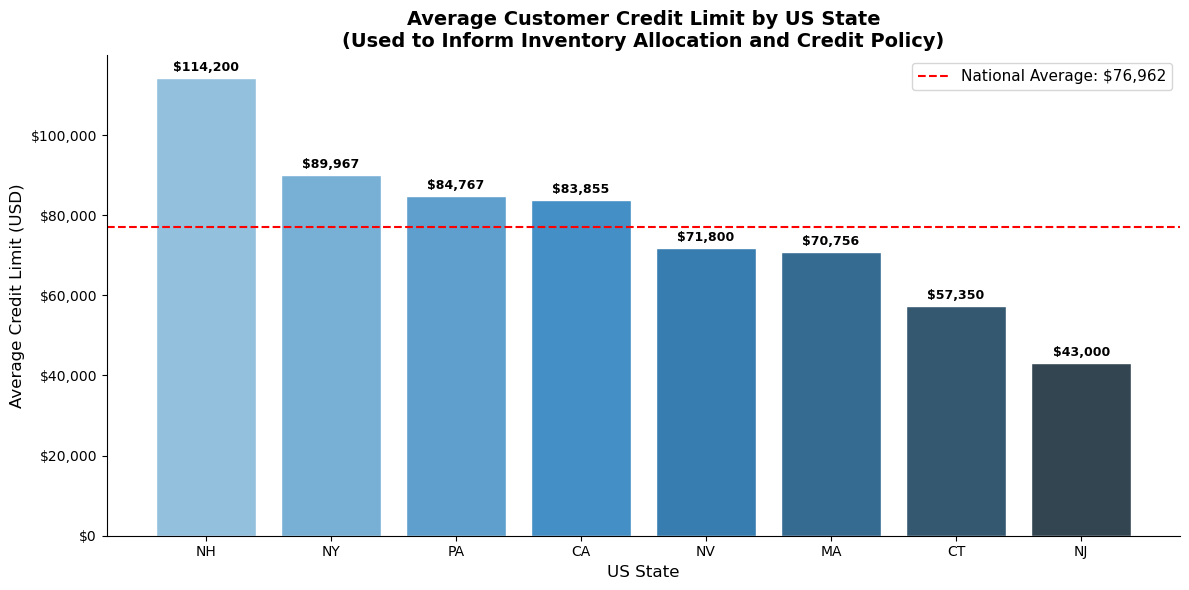

In [5]:
# Visualization: Average Credit Limit by US State
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette('Blues_d', len(usa_credit_by_state))
bars = ax.bar(usa_credit_by_state['state'],
              usa_credit_by_state['avgCreditLimit'],
              color=colors, edgecolor='white')

# Annotate each bar with the value
for bar, val in zip(bars, usa_credit_by_state['avgCreditLimit']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1000,
            f'${val:,.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add overall average reference line
overall_avg = usa_credit_by_state['avgCreditLimit'].mean()
ax.axhline(overall_avg, color='red', linestyle='--', linewidth=1.5,
           label=f'National Average: ${overall_avg:,.0f}')

ax.set_title('Average Customer Credit Limit by US State\n(Used to Inform Inventory Allocation and Credit Policy)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('US State', fontsize=12)
ax.set_ylabel('Average Credit Limit (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig('state_credit_limit.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 5: Top Customers

Return the top 10 customers by total payment amount for the company's 10-year anniversary acknowledgment.

In [6]:
query_5 = """
SELECT c.customerName,
       ROUND(SUM(p.amount), 2) AS totalPayments
FROM customers c
JOIN payments p ON c.customerNumber = p.customerNumber
GROUP BY c.customerNumber, c.customerName
ORDER BY totalPayments DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query_5, conn)
print('Top 10 Customers by Total Payments:')
top_customers

Top 10 Customers by Total Payments:


,customerName,totalPayments
0,Euro+ Shopping Channel,715738.98
1,Mini Gifts Distributors Ltd.,584188.24
2,"Australian Collectors, Co.",180585.07
3,Muscle Machine Inc,177913.95
4,"Dragon Souveniers, Ltd.",156251.03
5,"Down Under Souveniers, Inc",154622.08
6,"AV Stores, Co.",148410.09
7,"Anna's Decorations, Ltd",137034.22
8,Corporate Gift Ideas Co.,132340.78
9,"Saveley & Henriot, Co.",130305.35


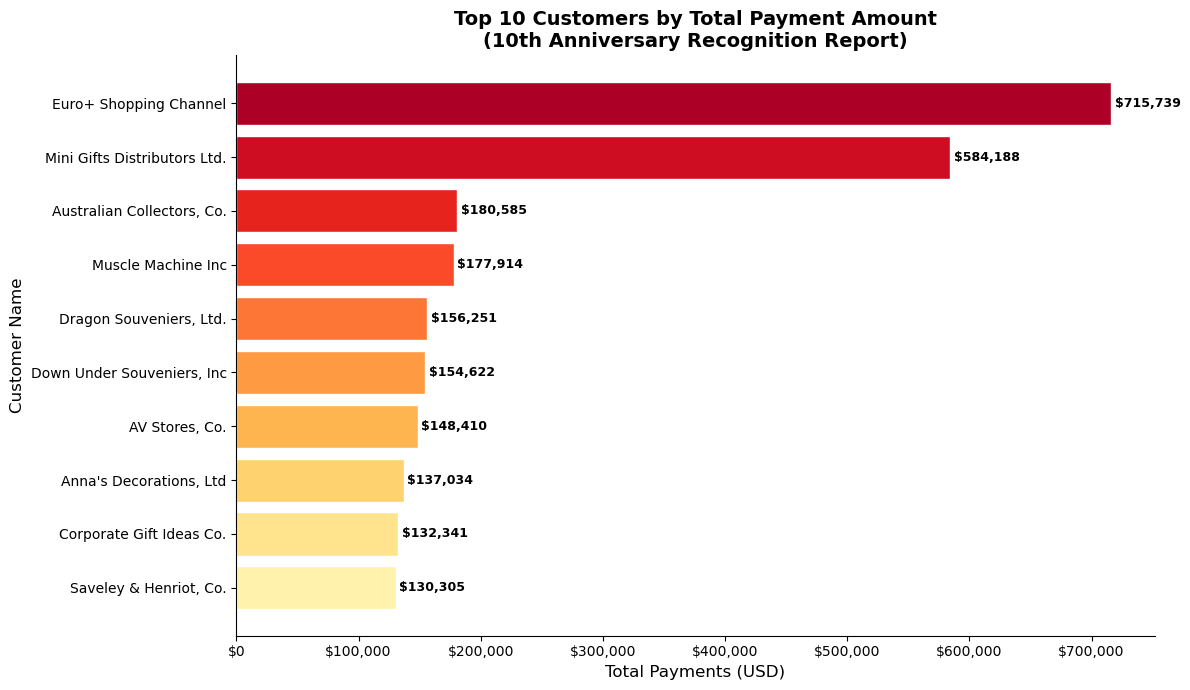

In [7]:
# Visualization: Top 10 Customers by Total Payments
fig, ax = plt.subplots(figsize=(12, 7))

# Sort ascending for horizontal bar (largest at top)
top_sorted = top_customers.sort_values('totalPayments')
colors = sns.color_palette('YlOrRd', len(top_sorted))

bars = ax.barh(top_sorted['customerName'],
               top_sorted['totalPayments'],
               color=colors, edgecolor='white')

# Annotate bars
for bar, val in zip(bars, top_sorted['totalPayments']):
    ax.text(bar.get_width() + 3000,
            bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}',
            va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 10 Customers by Total Payment Amount\n(10th Anniversary Recognition Report)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Payments (USD)', fontsize=12)
ax.set_ylabel('Customer Name', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig('top_customers.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 6: Top Customer + Product Quantities

For each customer, return any product they have purchased 10 or more units of, sorted ascending by total quantity.

In [8]:
query_6 = """
SELECT c.customerName,
       p.productName,
       p.productLine,
       SUM(od.quantityOrdered) AS totalQuantity
FROM customers c
JOIN orders o    ON c.customerNumber = o.customerNumber
JOIN orderdetails od ON o.orderNumber = od.orderNumber
JOIN products p  ON od.productCode = p.productCode
GROUP BY c.customerNumber, c.customerName, p.productCode, p.productName, p.productLine
HAVING SUM(od.quantityOrdered) >= 10
ORDER BY totalQuantity ASC;
"""

customer_product_quantities = pd.read_sql(query_6, conn)
print(f'Customer-product combinations with 10+ units ordered: {len(customer_product_quantities)}')
customer_product_quantities.head(15)

Customer-product combinations with 10+ units ordered: 2531


,customerName,productName,productLine,totalQuantity
0,Petit Auto,1913 Ford Model T Speedster,Vintage Cars,10
1,"Extreme Desk Decorations, Ltd",1961 Chevrolet Impala,Classic Cars,10
2,La Rochelle Gifts,1954 Greyhound Scenicruiser,Trucks and Buses,11
3,Tekni Collectables Inc.,American Airlines: B767-300,Planes,11
4,The Sharp Gifts Warehouse,1969 Chevrolet Camaro Z28,Classic Cars,13
5,Souveniers And Things Co.,1936 Mercedes Benz 500k Roadster,Vintage Cars,15
6,Salzburg Collectables,1982 Lamborghini Diablo,Classic Cars,15
7,L'ordine Souveniers,P-51-D Mustang,Planes,15
8,"Tokyo Collectables, Ltd",1936 Mercedes Benz 500k Roadster,Vintage Cars,15
9,"Extreme Desk Decorations, Ltd",1969 Dodge Super Bee,Classic Cars,16


## Step 7: Product Line Analysis

Return total quantity ordered and total number of distinct products per product line.

In [9]:
query_7 = """
SELECT pl.productLine,
       COUNT(DISTINCT p.productCode)  AS numProducts,
       SUM(od.quantityOrdered)        AS totalQuantityOrdered
FROM productlines pl
JOIN products p     ON pl.productLine = p.productLine
JOIN orderdetails od ON p.productCode  = od.productCode
GROUP BY pl.productLine
ORDER BY totalQuantityOrdered DESC;
"""

product_line_analysis = pd.read_sql(query_7, conn)
print('Product Line Analysis:')
product_line_analysis

Product Line Analysis:


,productLine,numProducts,totalQuantityOrdered
0,Classic Cars,37,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


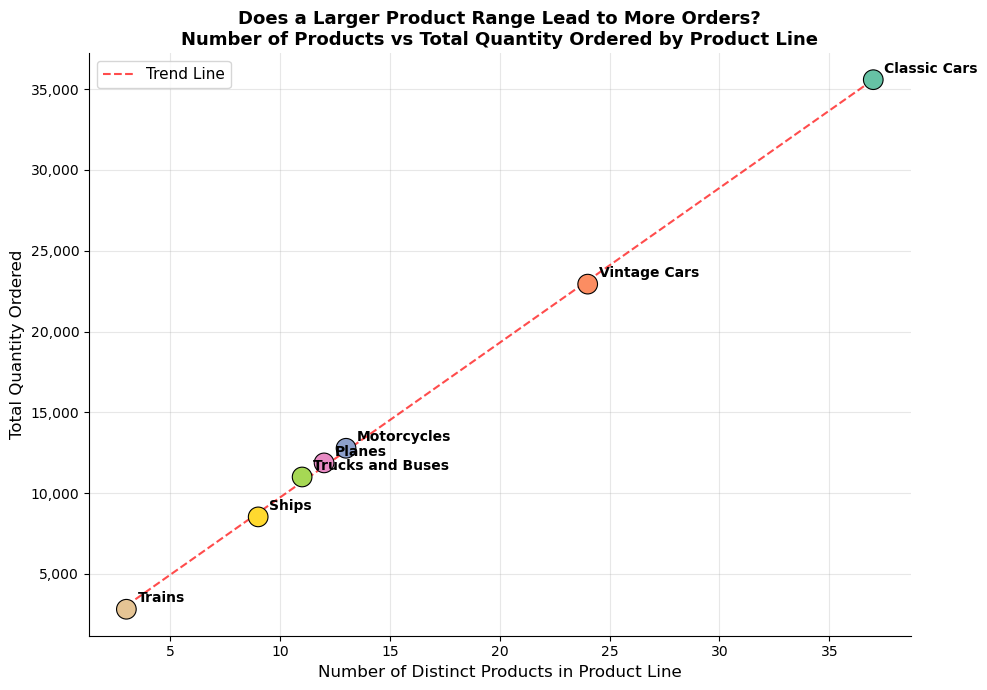

In [10]:
# Visualization: Scatter plot - Number of Products vs Total Quantity Ordered
fig, ax = plt.subplots(figsize=(10, 7))

colors = sns.color_palette('Set2', len(product_line_analysis))

scatter = ax.scatter(product_line_analysis['numProducts'],
                     product_line_analysis['totalQuantityOrdered'],
                     s=200, c=colors, edgecolors='black', linewidths=0.8, zorder=3)

# Label each point with the product line name
for _, row in product_line_analysis.iterrows():
    ax.annotate(row['productLine'],
                (row['numProducts'], row['totalQuantityOrdered']),
                textcoords='offset points', xytext=(8, 5),
                fontsize=10, fontweight='bold')

# Add a trend line
z = np.polyfit(product_line_analysis['numProducts'],
               product_line_analysis['totalQuantityOrdered'], 1)
p = np.poly1d(z)
x_line = np.linspace(product_line_analysis['numProducts'].min(),
                     product_line_analysis['numProducts'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend Line', alpha=0.7)

ax.set_title('Does a Larger Product Range Lead to More Orders?\nNumber of Products vs Total Quantity Ordered by Product Line',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Distinct Products in Product Line', fontsize=12)
ax.set_ylabel('Total Quantity Ordered', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('product_line_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

### Reflection - Step 7

**Why a scatter plot?**

A scatter plot was chosen because we are investigating the **relationship between two numeric variables** - the number of products in a product line and the total quantity ordered. Scatter plots are the ideal chart type for this purpose because each point represents one product line, and the position of the point along both axes simultaneously communicates both values. This makes it easy to visually spot whether there is a correlation between the two variables.

**What does this visual convey?**

The scatter plot, combined with the trend line, shows a **positive relationship** between the number of products in a line and total orders: product lines with more variety (like Classic Cars, with 37 products) tend to generate the most orders. However, this relationship is not perfectly linear; some lines, like ships, have moderate product counts but relatively lower order volumes. This suggests that while having more products generally helps drive orders, **product desirability and market interest** also play a significant role. The Trains line, for example, has the fewest products and the fewest orders, suggesting it may be a candidate for catalog expansion or review.

## Step 8: Remote Offices

Return employees working in offices with fewer than 5 employees, including their job title and supervisor information.

In [11]:
query_8 = """
SELECT e.employeeNumber,
       e.firstName,
       e.lastName,
       e.jobTitle,
       e.email,
       e.officeCode,
       o.city        AS officeCity,
       o.country     AS officeCountry,
       e.reportsTo   AS supervisorEmployeeNumber,
       mgr.firstName || ' ' || mgr.lastName AS supervisorName,
       mgr.jobTitle  AS supervisorTitle
FROM employees e
JOIN offices o ON e.officeCode = o.officeCode
LEFT JOIN employees mgr ON e.reportsTo = mgr.employeeNumber
WHERE e.officeCode IN (
    SELECT officeCode
    FROM employees
    GROUP BY officeCode
    HAVING COUNT(*) < 5
)
ORDER BY e.officeCode, e.lastName;
"""

remote_employees = pd.read_sql(query_8, conn)
print(f'Employees in offices with fewer than 5 staff: {len(remote_employees)}')
remote_employees

Employees in offices with fewer than 5 staff: 12


,employeeNumber,firstName,lastName,jobTitle,email,officeCode,officeCity,officeCountry,supervisorEmployeeNumber,supervisorName,supervisorTitle
0,1188,Julie,Firrelli,Sales Rep,jfirrelli@classicmodelcars.com,2,Boston,USA,1143,Anthony Bow,Sales Manager (NA)
1,1216,Steve,Patterson,Sales Rep,spatterson@classicmodelcars.com,2,Boston,USA,1143,Anthony Bow,Sales Manager (NA)
2,1286,Foon Yue,Tseng,Sales Rep,ftseng@classicmodelcars.com,3,NYC,USA,1143,Anthony Bow,Sales Manager (NA)
3,1323,George,Vanauf,Sales Rep,gvanauf@classicmodelcars.com,3,NYC,USA,1143,Anthony Bow,Sales Manager (NA)
4,1625,Yoshimi,Kato,Sales Rep,ykato@classicmodelcars.com,5,Tokyo,Japan,1621,Mami Nishi,Sales Rep
5,1621,Mami,Nishi,Sales Rep,mnishi@classicmodelcars.com,5,Tokyo,Japan,1056,Mary Patterson,VP Sales
6,1611,Andy,Fixter,Sales Rep,afixter@classicmodelcars.com,6,Sydney,Australia,1088,William Patterson,Sales Manager (APAC)
7,1619,Tom,King,Sales Rep,tking@classicmodelcars.com,6,Sydney,Australia,1088,William Patterson,Sales Manager (APAC)
8,1612,Peter,Marsh,Sales Rep,pmarsh@classicmodelcars.com,6,Sydney,Australia,1088,William Patterson,Sales Manager (APAC)
9,1088,William,Patterson,Sales Manager (APAC),wpatterson@classicmodelcars.com,6,Sydney,Australia,1056,Mary Patterson,VP Sales


### Reflection - Step 8

**How I decided on the subquery:**

The core challenge here is that the question requires filtering employees based on a property of their **office** (headcount), not a direct property of the employee themselves. This is a classic case for a subquery.

My thought process was:

1. **What do I ultimately want?** - A list of employees with their job and supervisor info.
2. **What filter determines which employees to include?** - Only those whose office has fewer than 5 total employees.
3. **How do I calculate office headcount?** - By grouping the employees table by `officeCode` and using `COUNT(*)`, filtered with `HAVING COUNT(*) < 5`. This naturally becomes the subquery.

The subquery `SELECT officeCode FROM employees GROUP BY officeCode HAVING COUNT(*) < 5` produces a list of office codes where headcount is below 5. The main query then uses `WHERE e.officeCode IN (...)` to keep only employees belonging to those offices. This approach is cleaner and more robust than hardcoding specific office codes, because it dynamically recalculates whenever the data changes.

## Step 9: Close the Connection

In [12]:
# Always close the database connection when finished
conn.close()
print('Database connection closed successfully.')

Database connection closed successfully.


---
# Part 2: Exploratory Analysis with SQL - Movie Database

In this section we explore the movie industry database (`im.db`) to identify interesting trends and formulate a business question for deeper analysis.

In [13]:
# Extract and connect to the movie database
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

conn4 = sqlite3.connect('im.db')

# Inspect schema
schema_df = pd.read_sql("SELECT * FROM sqlite_master WHERE type='table'", conn4)
print('Tables in movie database:')
schema_df[['name','sql']]

Tables in movie database:


,name,sql
0,movie_basics,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,directors,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,known_for,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,movie_akas,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,movie_ratings,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,persons,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,principals,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,writers,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


### Initial Exploration

In [14]:
# Explore movie_basics - scope of the dataset
basics_overview = pd.read_sql("""
SELECT COUNT(*) AS totalMovies,
       MIN(start_year) AS earliestYear,
       MAX(start_year) AS latestYear,
       COUNT(DISTINCT genres) AS uniqueGenreCombinations
FROM movie_basics
WHERE start_year IS NOT NULL
""", conn4)
print('Movie Basics Overview:')
basics_overview

Movie Basics Overview:


,totalMovies,earliestYear,latestYear,uniqueGenreCombinations
0,146144,2010,2115,1085


In [15]:
# Explore ratings distribution
ratings_overview = pd.read_sql("""
SELECT COUNT(*) AS moviesWithRatings,
       ROUND(AVG(averagerating), 2) AS meanRating,
       MIN(averagerating) AS minRating,
       MAX(averagerating) AS maxRating,
       ROUND(AVG(numvotes), 0) AS avgVotes,
       MAX(numvotes) AS maxVotes
FROM movie_ratings
WHERE averagerating IS NOT NULL
""", conn4)
print('Ratings Overview:')
ratings_overview

Ratings Overview:


,moviesWithRatings,meanRating,minRating,maxRating,avgVotes,maxVotes
0,73856,6.33,1.0,10.0,3524.0,1841066


In [16]:
# Top genres by average rating (with enough votes to be meaningful)
genre_ratings = pd.read_sql("""
SELECT mb.genres,
       COUNT(*) AS numMovies,
       ROUND(AVG(mr.averagerating), 2) AS avgRating,
       ROUND(AVG(mr.numvotes), 0) AS avgVotes
FROM movie_basics mb
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
WHERE mb.genres IS NOT NULL
  AND mr.numvotes > 1000
GROUP BY mb.genres
HAVING COUNT(*) >= 20
ORDER BY avgRating DESC
LIMIT 15;
""", conn4)
print('Top Genres by Average Rating (min 1000 votes, min 20 movies):')
genre_ratings

Top Genres by Average Rating (min 1000 votes, min 20 movies):


,genres,numMovies,avgRating,avgVotes
0,"Documentary,Sport",25,7.71,3446.0
1,"Biography,Documentary,Music",25,7.64,7559.0
2,"Biography,Documentary,History",23,7.50,4169.0
3,"Biography,Documentary,Sport",26,7.33,4828.0
4,"Documentary,History",24,7.27,2652.0
5,"Biography,Documentary",41,7.27,3600.0
6,"Documentary,Music",50,7.23,6663.0
7,"Crime,Documentary",20,7.18,9667.0
8,"Action,Adventure,Animation",64,7.13,55400.0
9,"Drama,Family",24,7.12,8284.0


In [17]:
# Does runtime affect ratings? Explore runtime vs average rating
runtime_ratings = pd.read_sql("""
SELECT 
    CASE
        WHEN mb.runtime_minutes < 60  THEN 'Under 60 min'
        WHEN mb.runtime_minutes < 90  THEN '60-89 min'
        WHEN mb.runtime_minutes < 120 THEN '90-119 min'
        WHEN mb.runtime_minutes < 150 THEN '120-149 min'
        ELSE '150+ min'
    END AS runtimeBucket,
    COUNT(*) AS numMovies,
    ROUND(AVG(mr.averagerating), 2) AS avgRating
FROM movie_basics mb
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
WHERE mb.runtime_minutes IS NOT NULL
  AND mr.numvotes > 500
GROUP BY runtimeBucket
ORDER BY avgRating DESC;
""", conn4)
print('Average Rating by Runtime Bucket:')
runtime_ratings

Average Rating by Runtime Bucket:


,runtimeBucket,numMovies,avgRating
0,Under 60 min,46,6.92
1,150+ min,564,6.85
2,120-149 min,2102,6.70
3,90-119 min,8249,6.11
4,60-89 min,2866,5.61


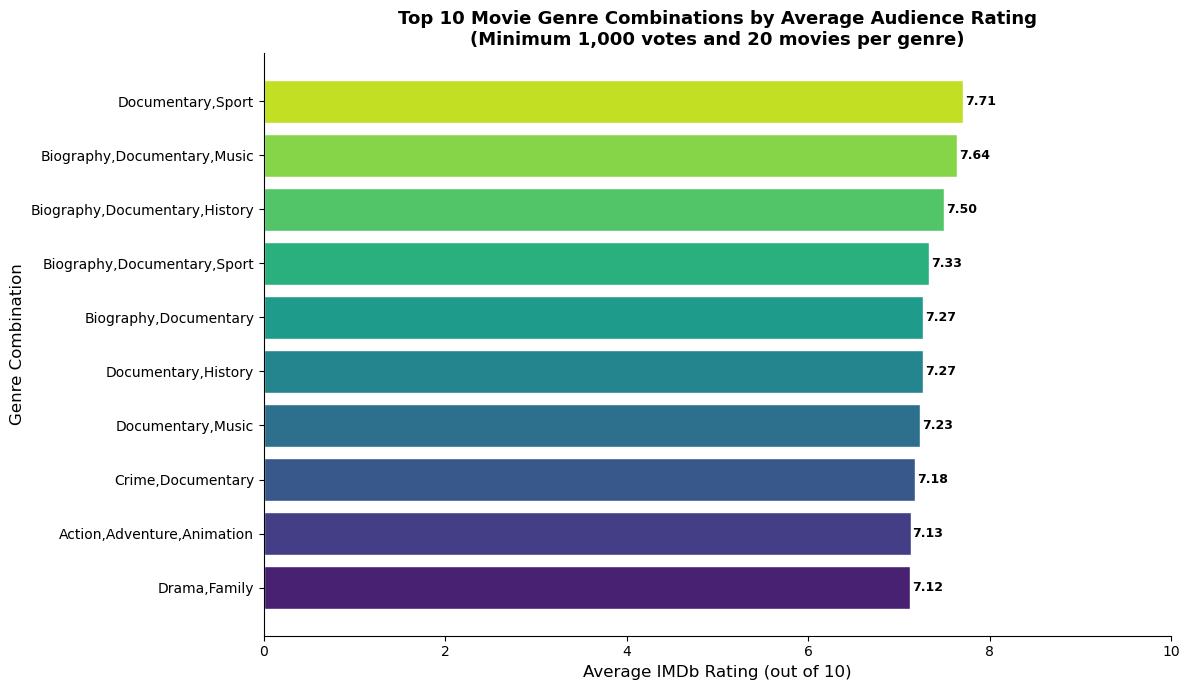

In [18]:
# Visualization: Average Rating by Genre (Top 10)
top10_genres = genre_ratings.head(10).sort_values('avgRating')

fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette('viridis', len(top10_genres))
bars = ax.barh(top10_genres['genres'], top10_genres['avgRating'],
               color=colors, edgecolor='white')

for bar, val in zip(bars, top10_genres['avgRating']):
    ax.text(bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}',
            va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 10 Movie Genre Combinations by Average Audience Rating\n(Minimum 1,000 votes and 20 movies per genre)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average IMDb Rating (out of 10)', fontsize=12)
ax.set_ylabel('Genre Combination', fontsize=12)
ax.set_xlim(0, 10)
sns.despine()
plt.tight_layout()
plt.savefig('genre_ratings.png', bbox_inches='tight', dpi=150)
plt.show()

### Business Question Formulation

**Business Question:** *Do movies with longer runtimes receive higher audience ratings, and which genres benefit most from longer formats?*

**Rationale:** The initial exploration revealed that longer movies (120+ minutes) tend to score higher on average than shorter films. This is relevant for studios deciding how to greenlight and market projects. If certain genres consistently reward longer storytelling, studios could adjust their production strategies accordingly. A deeper analysis joining `movie_basics`, `movie_ratings` to examine runtime-by-genre interactions could yield actionable insights for content investment decisions.

### Data Cleaning Assessment

The following data cleaning tasks were identified during exploration:

1. **Null values in `runtime_minutes`** - Many movies have no recorded runtime. These rows must be excluded from any runtime analysis.

2. **Null values in `genres`** - Some movies have no genre listed (`\\N` placeholder in raw data). These should be filtered out before genre-level aggregation.

3. **`start_year` stored as text** — The year column contains `\\N` placeholders for missing values instead of NULL. These must be handled before any time-series analysis.

4. **Genre combinations vs. single genres** — Genres are stored as comma-separated strings (e.g., `'Action,Comedy'`). For single-genre analysis, these would need to be split and normalized into individual rows.

5. **Low vote count movies skewing ratings** — Movies with very few votes can have extreme ratings (1.0 or 10.0) that don't reflect broad audience opinion. A minimum vote threshold (e.g., 500–1,000 votes) should be applied.

6. **Duplicate `person_id` entries in `principals`** — A person can appear multiple times per movie in different roles. Deduplication logic is needed depending on the analysis.

7. **`death_year` nulls in `persons`** — Living persons have no death year. This is expected but must be handled carefully to avoid treating nulls as missing data errors.

In [19]:
# Close movie database connection
conn4.close()
print('Movie database connection closed.')

Movie database connection closed.
